In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import ssqueezepy as sq

fs = 2.0
dt = 1 / fs
T = 2000
t = np.arange(0, T, dt)

f0 = 0.024
A = 1.0

x = A * np.sin(2 * np.pi * f0 * t)

print("Time-domain power:", np.mean(x**2))

Time-domain power: 0.5000000000000001


In [7]:
wlt = sq.Wavelet('morlet')

In [16]:
res = []

for A in np.arange(0.2, 15, 0.2):
    x = A * np.sin(2 * np.pi * f0 * t)

    coef, scales = sq.cwt(x, wavelet=wlt, fs=fs)

    freqs_cwt = sq.experimental.scale_to_freq(scales, wavelet=wlt, N=t.size, fs=fs)
    
    power_cwt = np.abs(coef)**2
    cwt_band_power_raw = np.trapz(power_cwt, freqs_cwt, axis=0)

    
    res.append([A, cwt_band_power_raw.mean()])
    
res = np.array(res)

Text(0.5, 0, 'Oscillation amplitude, A')

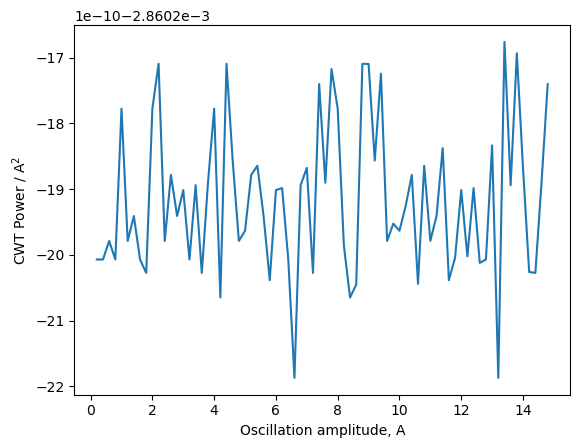

In [17]:
plt.plot(res[:, 0], res[:, 1]/res[:, 0]**2)
plt.ylabel('CWT Power / A$^2$')
plt.xlabel('Oscillation amplitude, A')